# Ensemble Learning: Random Forest Regression on a Synthetic Curve

---

## Introduction

**Random Forest Regression** is an ensemble method that builds many `DecisionTreeRegressor` instances, each trained on a different bootstrap sample of the data with a random feature subset, and averages their predictions. This averaging reduces the high variance of individual decision trees, producing smoother and more generalizable predictions.

This notebook demonstrates the contrast between a single `DecisionTreeRegressor` and a `RandomForestRegressor` on a 1D synthetic regression problem. The target function is a sum of two Gaussian bumps:

$$f(x) = e^{-x^2} + 1.5 \cdot e^{-(x-2)^2}$$

This function is smooth and non-linear, making it a good benchmark to visually expose the jagged overfitting of a single decision tree versus the smooth approximation of a forest.

### Workflow

1. Define the target function and generate noisy train and test datasets
2. Visualize the true function and training data
3. Fit a single `DecisionTreeRegressor` and evaluate its prediction curve
4. Fit a `RandomForestRegressor` (1000 trees) and evaluate its prediction curve
5. Compare both models side by side

---

## 1. Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

---

## 2. Target Function and Dataset Generation

The true function $f(x) = e^{-x^2} + 1.5 \cdot e^{-(x-2)^2}$ produces two overlapping Gaussian peaks over the domain $[-5, 5]$. Gaussian noise is added to the training and test samples to simulate real-world measurement error.

| Split | Samples | Purpose |
|---|---|---|
| Train | 150 | Fit the regressors |
| Test | 1000 | Dense grid for smooth prediction curves |

In [2]:
# Configuration
N_TRAIN = 150
N_TEST  = 1000
NOISE   = 0.1

def f(X):
    """True underlying function: sum of two Gaussian bumps."""
    X = X.ravel()
    return np.exp(-X**2) + 1.5 * np.exp(-(X - 2)**2)

def generate(n_samples, noise):
    """Generate noisy samples from f(x) over [-5, 5]."""
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = f(X) + np.random.normal(0.0, noise, n_samples)
    return X.reshape(n_samples, 1), y

X_train, y_train = generate(N_TRAIN, NOISE)
X_test,  y_test  = generate(N_TEST,  NOISE)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")

Train : (150, 1)
Test  : (1000, 1)


### 2.1 Visualizing the True Function and Training Data

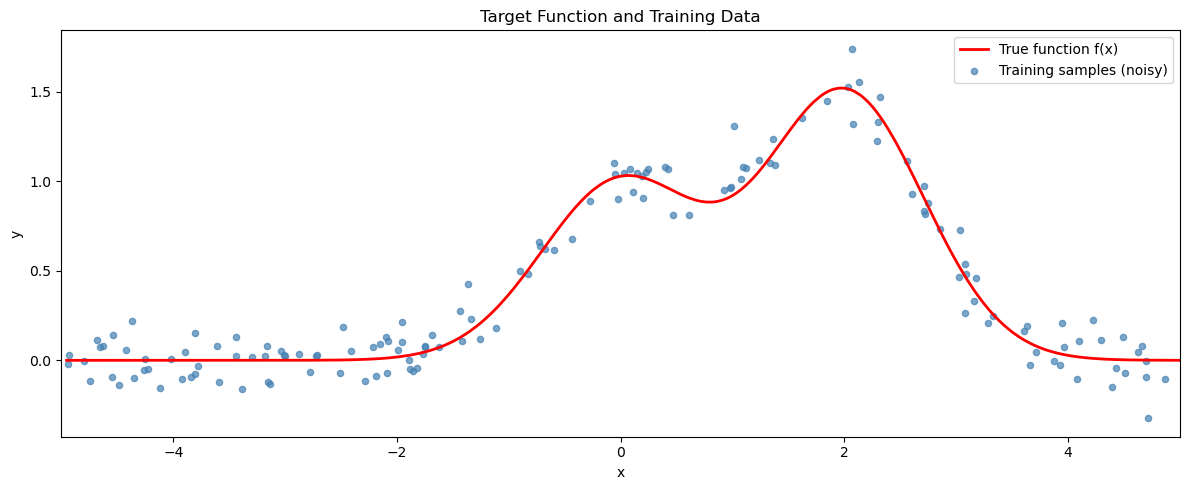

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples (noisy)')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Target Function and Training Data')
plt.legend()
plt.tight_layout()
plt.show()

---

## 3. Baseline: Single Decision Tree Regressor

A single `DecisionTreeRegressor` with no depth constraint fits the training data by learning axis-aligned step functions. On dense test data this produces a jagged, overfitted prediction curve — the tree memorizes the training noise rather than the underlying smooth signal.

In [13]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(f"Decision Tree  —  R²: {r2_score(y_test, y_pred_dt):.4f}   "
      f"RMSE: {mean_squared_error(y_test, y_pred_dt,):.4f}")

Decision Tree  —  R²: 0.9278   RMSE: 0.0193


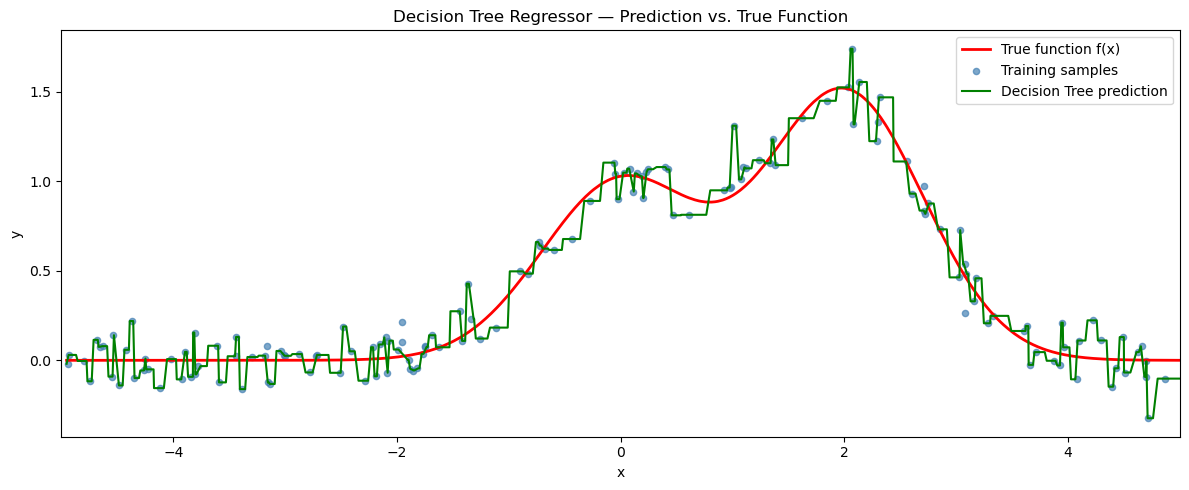

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples')
plt.plot(X_test, y_pred_dt, 'g', lw=1.5, label='Decision Tree prediction')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Decision Tree Regressor — Prediction vs. True Function')
plt.legend()
plt.tight_layout()
plt.show()

---

## 4. Random Forest Regressor

A `RandomForestRegressor` with 1000 trees averages the predictions of 1000 independently trained decision trees, each built on a different bootstrap sample and random feature subset. The averaging smooths out the jagged step-function artifacts and produces a prediction curve that tracks the true function much more closely.

In [8]:
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(f"Random Forest  —  R²: {r2_score(y_test, y_pred_rf):.4f}   "
      f"RMSE: {mean_squared_error(y_test, y_pred_rf,):.4f}")

Random Forest  —  R²: 0.9465   RMSE: 0.0143


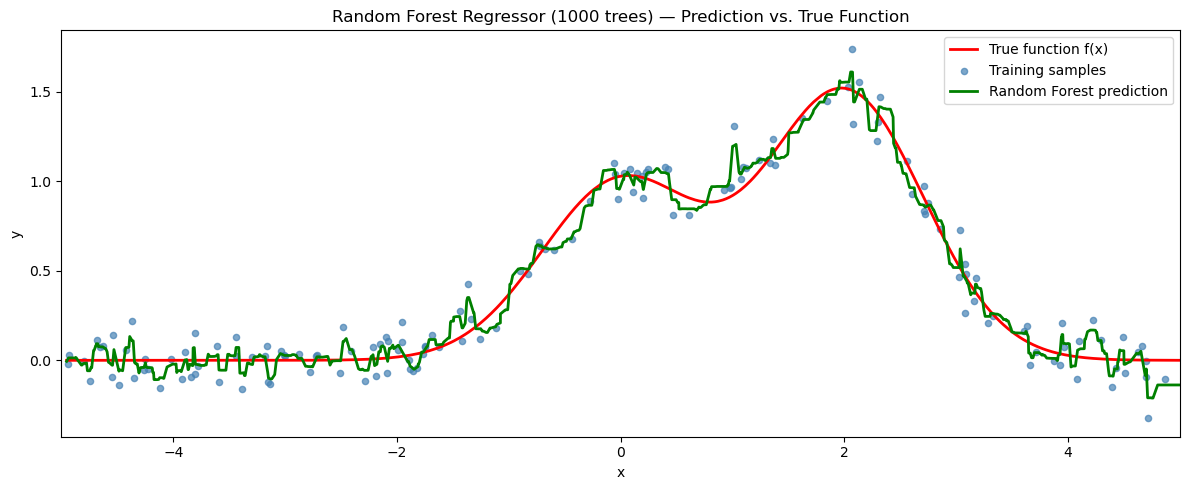

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(X_test, f(X_test), 'r', lw=2, label='True function f(x)')
plt.scatter(X_train, y_train, c='steelblue', s=20, alpha=0.7, label='Training samples')
plt.plot(X_test, y_pred_rf, 'g', lw=2, label='Random Forest prediction')
plt.xlim([-5, 5])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Forest Regressor (1000 trees) — Prediction vs. True Function')
plt.legend()
plt.tight_layout()
plt.show()

---

## 5. Side-by-Side Comparison

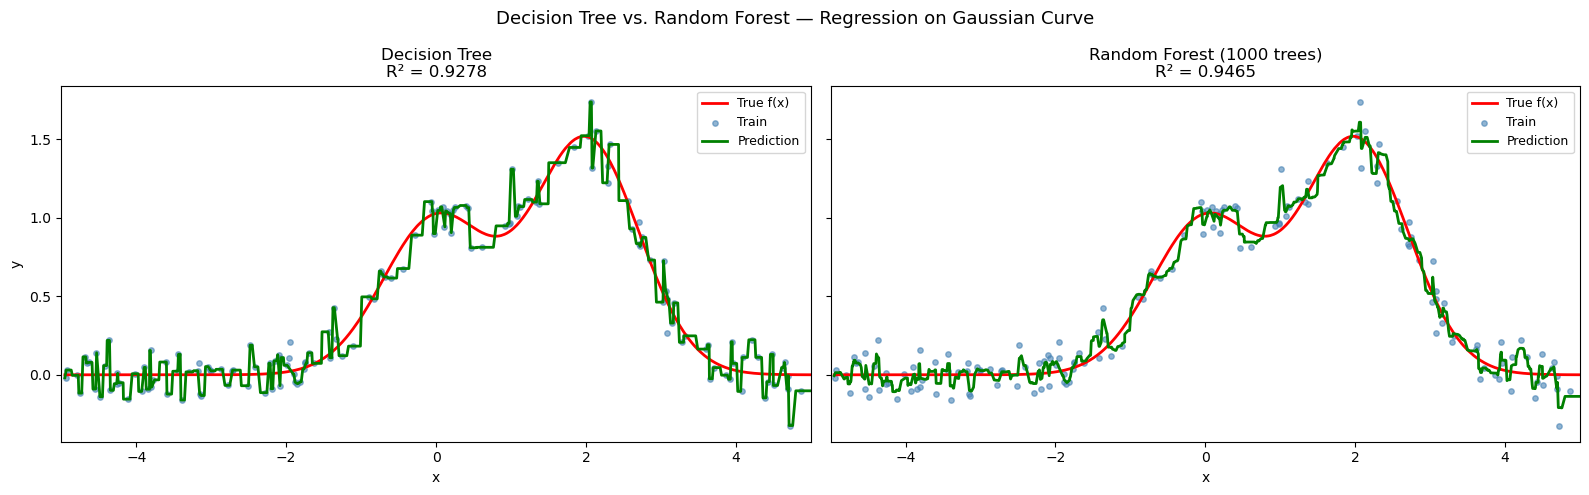

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt, y_pred_rf],
    ['Decision Tree', 'Random Forest (1000 trees)']
):
    ax.plot(X_test, f(X_test), 'r', lw=2, label='True f(x)')
    ax.scatter(X_train, y_train, c='steelblue', s=15, alpha=0.6, label='Train')
    ax.plot(X_test, y_pred, 'g', lw=2, label='Prediction')
    ax.set_xlim([-5, 5])
    ax.set_xlabel('x')
    ax.set_title(f"{title}\nR² = {r2_score(y_test, y_pred):.4f}")
    ax.legend(fontsize=9)

axes[0].set_ylabel('y')
plt.suptitle('Decision Tree vs. Random Forest — Regression on Gaussian Curve', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Results Summary

In [12]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest (1000 trees)'],
    'R²':   [round(r2_score(y_test, y_pred_dt), 4),
              round(r2_score(y_test, y_pred_rf), 4)],
    'RMSE': [round(mean_squared_error(y_test, y_pred_dt,), 4),
             round(mean_squared_error(y_test, y_pred_rf,), 4)]
})

print(results.to_string(index=False))

                     Model     R²   RMSE
             Decision Tree 0.9278 0.0193
Random Forest (1000 trees) 0.9465 0.0143


---

## Conclusion

This notebook demonstrated the difference between a single `DecisionTreeRegressor` and a `RandomForestRegressor` on a smooth 1D regression problem.

**Key findings:**

- The single decision tree produces a characteristic **staircase prediction curve** — it fits the training points closely but fails to capture the smooth shape of the true function. This is a direct consequence of high variance: the tree memorizes training noise and generalizes poorly.
- The Random Forest with 1000 trees produces a **smooth prediction curve** that closely tracks the true Gaussian function. By averaging 1000 independently trained trees, individual overfit artifacts cancel out and the ensemble converges toward the true expectation of the function.
- The improvement in R² and RMSE confirms quantitatively what the plots show visually: the ensemble dramatically reduces prediction error on unseen data.

**Takeaways:**

- The 1D nature of this problem makes the variance-reduction effect of averaging uniquely visible — the jagged tree gives way to a smooth curve as more trees are added.
- `n_estimators=1000` is a generous setting; in practice, accuracy gains plateau well before that. A good starting point is 100–300 trees, monitored via OoB score.
- `n_jobs=-1` enables parallel tree training across all CPU cores, which is important at scale since each tree is trained independently.
- The next step in the ensemble progression is **Gradient Boosting**, which instead of averaging parallel trees, fits each new tree sequentially to the residual errors of the previous ensemble.